<a href="https://colab.research.google.com/github/eoindarlington/Electric-Cars-/blob/main/Electric_Cars_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

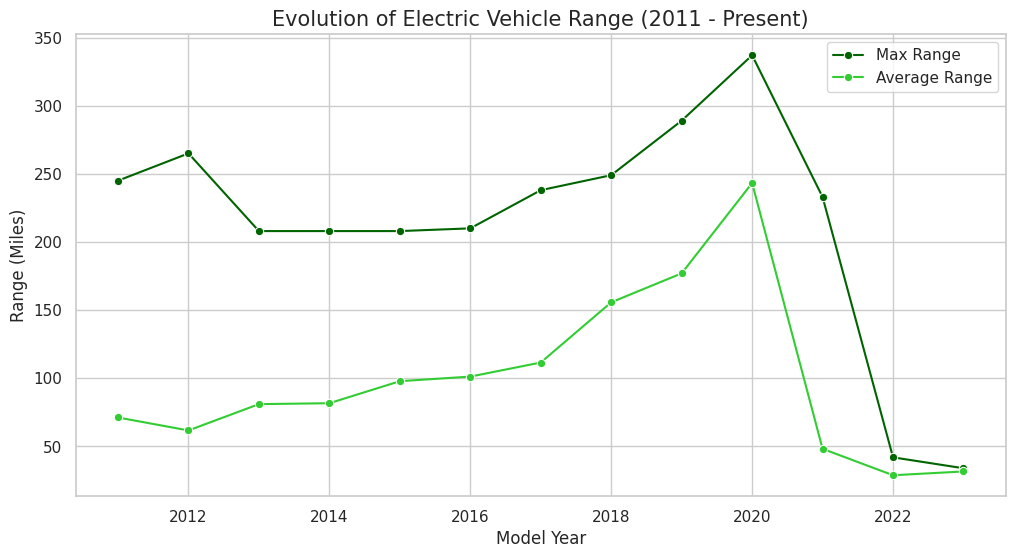

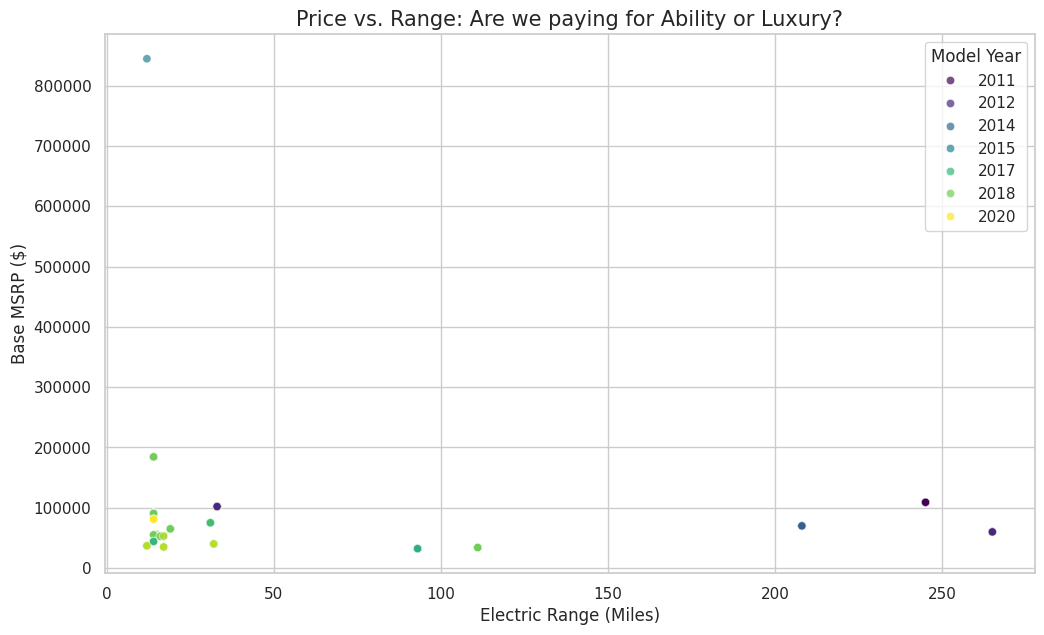

/tmp/ipykernel_6663/1731556727.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_price_per_mile, x='Model Year', y='Price_Per_Mile', palette='magma')


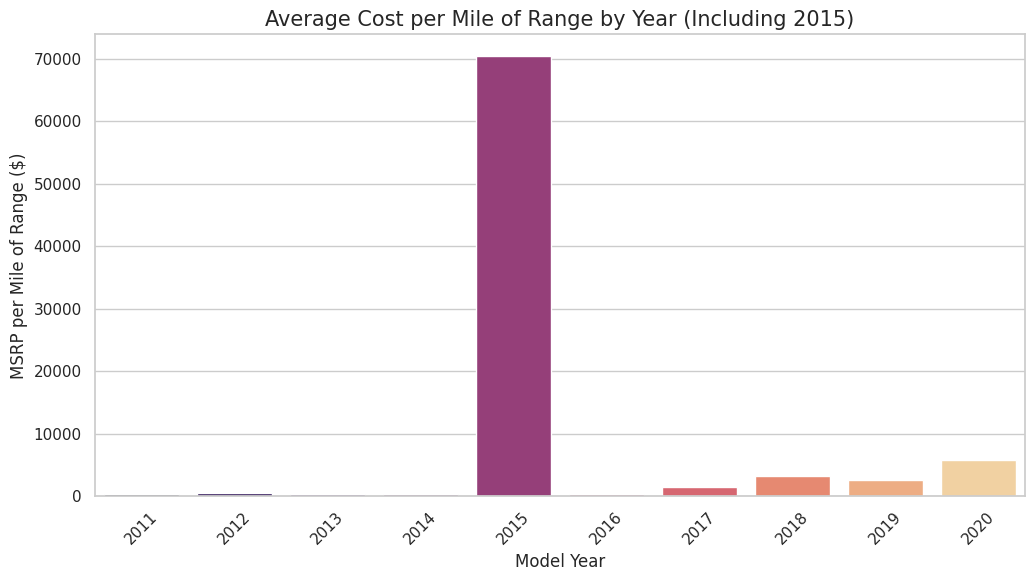

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Electric_Vehicle_Population_Data.csv')

#Filter out rows where Range or MSRP is 0 to get accurate averages
#Filter for years where EVs had a significant market presence (e.g., post-2010)
df_clean = df[(df['Electric Range'] > 0) & (df['Model Year'] > 2010)].copy()
df_price = df_clean[df_clean['Base MSRP'] > 0].copy()

# Set the visual style
sns.set_theme(style="whitegrid")

#Range Evolution
plt.figure(figsize=(12, 6))
range_stats = df_clean.groupby('Model Year')['Electric Range'].agg(['mean', 'max']).reset_index()

sns.lineplot(data=range_stats, x='Model Year', y='max', label='Max Range', marker='o', color='darkgreen')
sns.lineplot(data=range_stats, x='Model Year', y='mean', label='Average Range', marker='o', color='limegreen')

plt.title('Evolution of Electric Vehicle Range (2011 - Present)', fontsize=15)
plt.ylabel('Range (Miles)')
plt.xlabel('Model Year')
plt.legend()
plt.show()

#Price vs Range (The "Luxury vs Ability" Scatter")
plt.figure(figsize=(12, 7))

# We use a scatter plot with Hue for Year to see the progression
scatter = sns.scatterplot(
    data=df_price,
    x='Electric Range',
    y='Base MSRP',
    hue='Model Year',
    palette='viridis',
    alpha=0.7
)

plt.title('Price vs. Range: Are we paying for Ability or Luxury?', fontsize=15)
plt.xlabel('Electric Range (Miles)')
plt.ylabel('Base MSRP ($)')
plt.show()

# Value for Money (Price per Mile) - Including 2015
# Create the calculated column
df_price['Price_Per_Mile'] = df_price['Base MSRP'] / df_price['Electric Range']

plt.figure(figsize=(12, 6))
avg_price_per_mile = df_price.groupby('Model Year')['Price_Per_Mile'].mean().reset_index()

sns.barplot(data=avg_price_per_mile, x='Model Year', y='Price_Per_Mile', palette='magma')

plt.title('Average Cost per Mile of Range by Year (Including 2015)', fontsize=15)
plt.ylabel('MSRP per Mile of Range ($)')
plt.xlabel('Model Year')
plt.xticks(rotation=45)
plt.show()

We Exclude 2015 because this year our data only has one point, and it is for a Porsche 918 Spyder. This car is $850,000 and only has 12 miles of range, which immplies that the car is ~$70,000 for each mile of electric range. And hides out the other parts of our data.

/tmp/ipykernel_35723/3665557158.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_price_per_mile_excluding_2015, x='Model Year', y='Price_Per_Mile', palette='magma')


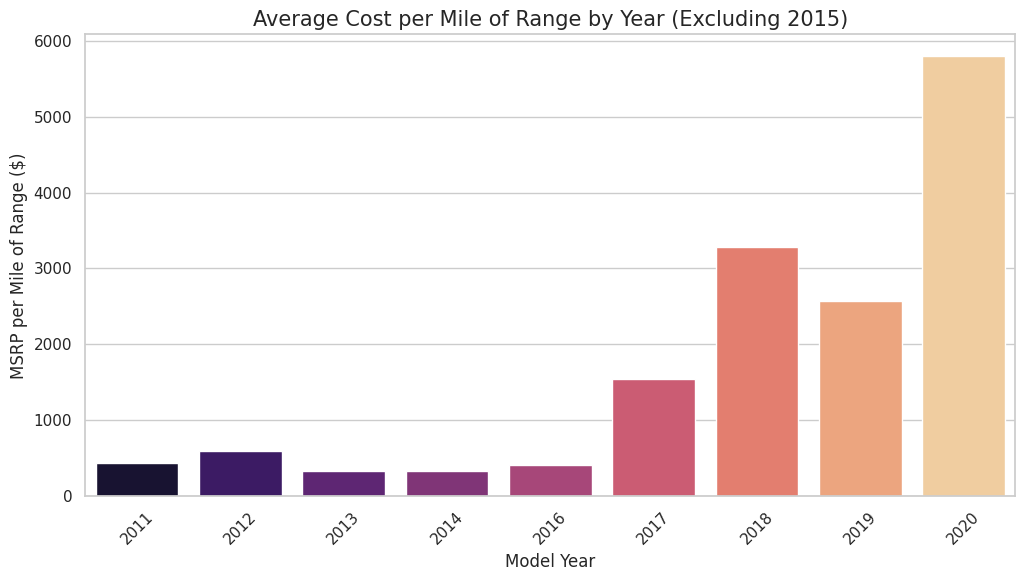

In [ ]:
#Value for Money (Price per Mile) - Excluding 2015

# Filter out 2015 data for this specific graph
df_price_filtered_excluding_2015 = df_price[df_price['Model Year'] != 2015].copy()

plt.figure(figsize=(12, 6))
avg_price_per_mile_excluding_2015 = df_price_filtered_excluding_2015.groupby('Model Year')['Price_Per_Mile'].mean().reset_index()

sns.barplot(data=avg_price_per_mile_excluding_2015, x='Model Year', y='Price_Per_Mile', palette='magma')

plt.title('Average Cost per Mile of Range by Year (Excluding 2015)', fontsize=15)
plt.ylabel('MSRP per Mile of Range ($)')
plt.xlabel('Model Year')
plt.xticks(rotation=45)
plt.show()